# 01 — EDA: Model Analisa Makanan (Food Scan Analyzer)

**Tujuan:** Eksplorasi food_master_v3.parquet sebagai basis database Model 4.

**Input:** `food_master_v3.parquet` (1,346 makanan Indonesia)

**Output:**
- `output/eda/eda_summary.json`
- `output/eda/category_distribution.png`
- `output/eda/nutrition_distributions.png`

In [1]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

os.makedirs('output/eda', exist_ok=True)

FOOD_MASTER_PATH = '../Model_Perencana_Makan/output/preprocessed/food_master_v3.parquet'
df = pd.read_parquet(FOOD_MASTER_PATH)
print(f'Food master: {df.shape}')
print(f'Kolom: {list(df.columns)}')
df.head()

Food master: (1346, 20)
Kolom: ['id', 'slug', 'name', 'category', 'cuisine', 'calories_per_portion', 'protein_g', 'fat_g', 'carbs_g', 'estimated_price_idr', 'is_halal', 'is_vegetarian', 'is_vegan', 'is_gluten_free', 'image_url', 'base_portion', 'base_portion_gram', 'fiber_g', 'is_active', 'cal_per_1000_idr']


,id,slug,name,category,cuisine,calories_per_portion,protein_g,fat_g,carbs_g,estimated_price_idr,is_halal,is_vegetarian,is_vegan,is_gluten_free,image_url,base_portion,base_portion_gram,fiber_g,is_active,cal_per_1000_idr
0,1,abon,Abon,STAPLE,INDONESIAN_GENERAL,280.0,9.2,28.4,0.0,12000,True,True,True,True,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...,1 porsi,100,0.0,True,23.3
1,2,abon-haruwan,Abon haruwan,STAPLE,INDONESIAN_GENERAL,513.0,23.7,37.0,21.3,18500,True,True,True,True,https://img-global.cpcdn.com/recipes/cbf330fbd...,1 porsi,100,0.0,True,27.7
2,3,agar-agar,Agar-agar,STAPLE,INDONESIAN_GENERAL,1.0,0.0,0.2,0.0,8500,True,True,True,True,https://res.cloudinary.com/dk0z4ums3/image/upl...,1 porsi,100,0.0,False,0.1
3,4,akar-tonjong-segar,Akar tonjong segar,STAPLE,INDONESIAN_GENERAL,45.0,1.1,0.4,10.8,9000,True,True,True,True,https://images.tokopedia.net/img/cache/200-squ...,1 porsi,100,0.0,True,5.0
4,5,aletoge-segar,Aletoge segar,STAPLE,INDONESIAN_GENERAL,37.0,4.4,0.5,3.8,7500,True,True,True,True,https://nilaigizi.com/assets/images/produk/pro...,1 porsi,100,0.0,True,4.9


In [2]:
# ── 1. Basic Stats ──
print(df.dtypes)
print()
print(df.describe().round(2))
print(f'\nMissing values:')
print(df.isnull().sum())

id                        int64
slug                     object
name                     object
category                 object
cuisine                  object
calories_per_portion    float64
protein_g               float64
fat_g                   float64
carbs_g                 float64
estimated_price_idr       int64
is_halal                   bool
is_vegetarian              bool
is_vegan                   bool
is_gluten_free             bool
image_url                object
base_portion             object
base_portion_gram         int64
fiber_g                 float64
is_active                  bool
cal_per_1000_idr        float64
dtype: object

            id  calories_per_portion  protein_g    fat_g  carbs_g  \
count  1346.00               1346.00    1346.00  1346.00  1346.00   
mean    673.50                195.78       9.83     7.02    24.99   
std     388.70                146.51      11.60    11.51    31.82   
min       1.00                  1.00       0.00     0.00     0.00   


In [3]:
# ── 2. Name Analysis ──
df['name_length'] = df['name'].str.len()
df['word_count']  = df['name'].str.split().str.len()

print(f'Avg name length: {df["name_length"].mean():.1f} karakter')
print(f'Avg word count:  {df["word_count"].mean():.1f} kata')
print(f'Max name length: {df["name_length"].max()} ({df.loc[df["name_length"].idxmax(), "name"]})')
print(f'\nTop 25 kata paling umum dalam nama makanan:')
all_words = ' '.join(df['name'].str.lower()).split()
for word, count in Counter(all_words).most_common(25):
    print(f'  {word:20s} {count}x')

Avg name length: 15.9 karakter
Avg word count:  2.6 kata
Max name length: 37 (Pisang angleng (pisang ampyang) segar)

Top 25 kata paling umum dalam nama makanan:
  segar                283x
  ikan                 128x
  kacang               98x
  daun                 90x
  goreng               76x
  masakan              72x
  mentah               57x
  kering               56x
  daging               43x
  beras                37x
  sapi                 35x
  merah                32x
  ubi                  31x
  putih                30x
  jagung               30x
  tepung               29x
  kukus                28x
  ayam                 28x
  rebus                28x
  pisang               27x
  kuning               24x
  telur                23x
  tempe                23x
  biji                 22x
  singkong             22x


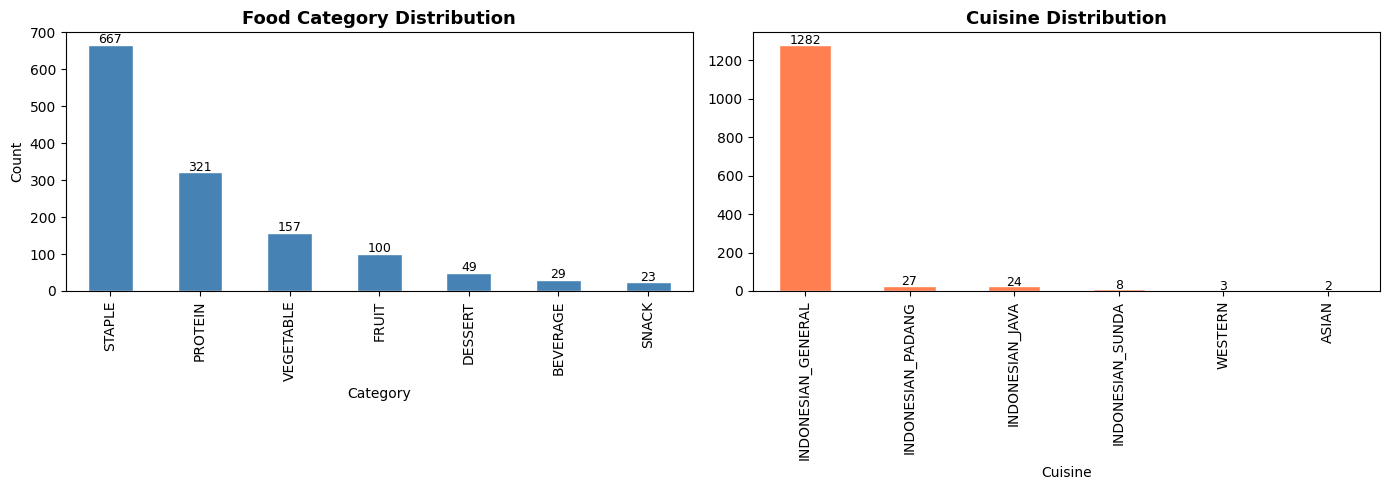


Category breakdown:
{'STAPLE': 667, 'PROTEIN': 321, 'VEGETABLE': 157, 'FRUIT': 100, 'DESSERT': 49, 'BEVERAGE': 29, 'SNACK': 23}


In [4]:
# ── 3. Category & Cuisine Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts = df['category'].value_counts()
cat_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Food Category Distribution', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(int(bar.get_height())), ha='center', fontsize=9)

cui_counts = df['cuisine'].value_counts()
cui_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Cuisine Distribution', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Cuisine')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(int(bar.get_height())), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('output/eda/category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nCategory breakdown:\n{cat_counts.to_dict()}')

C:\Users\Asus\AppData\Local\Temp\ipykernel_34924\2640731956.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_cat, labels=df['category'].unique(), patch_artist=True)
C:\Users\Asus\AppData\Local\Temp\ipykernel_34924\2640731956.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_cat, labels=df['category'].unique(), patch_artist=True)
C:\Users\Asus\AppData\Local\Temp\ipykernel_34924\2640731956.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_cat, labels=df['category'].unique(), patch_artist=True)
C:\Users\Asus\AppData\Local\Temp\ipykernel_34924\2640731956.p

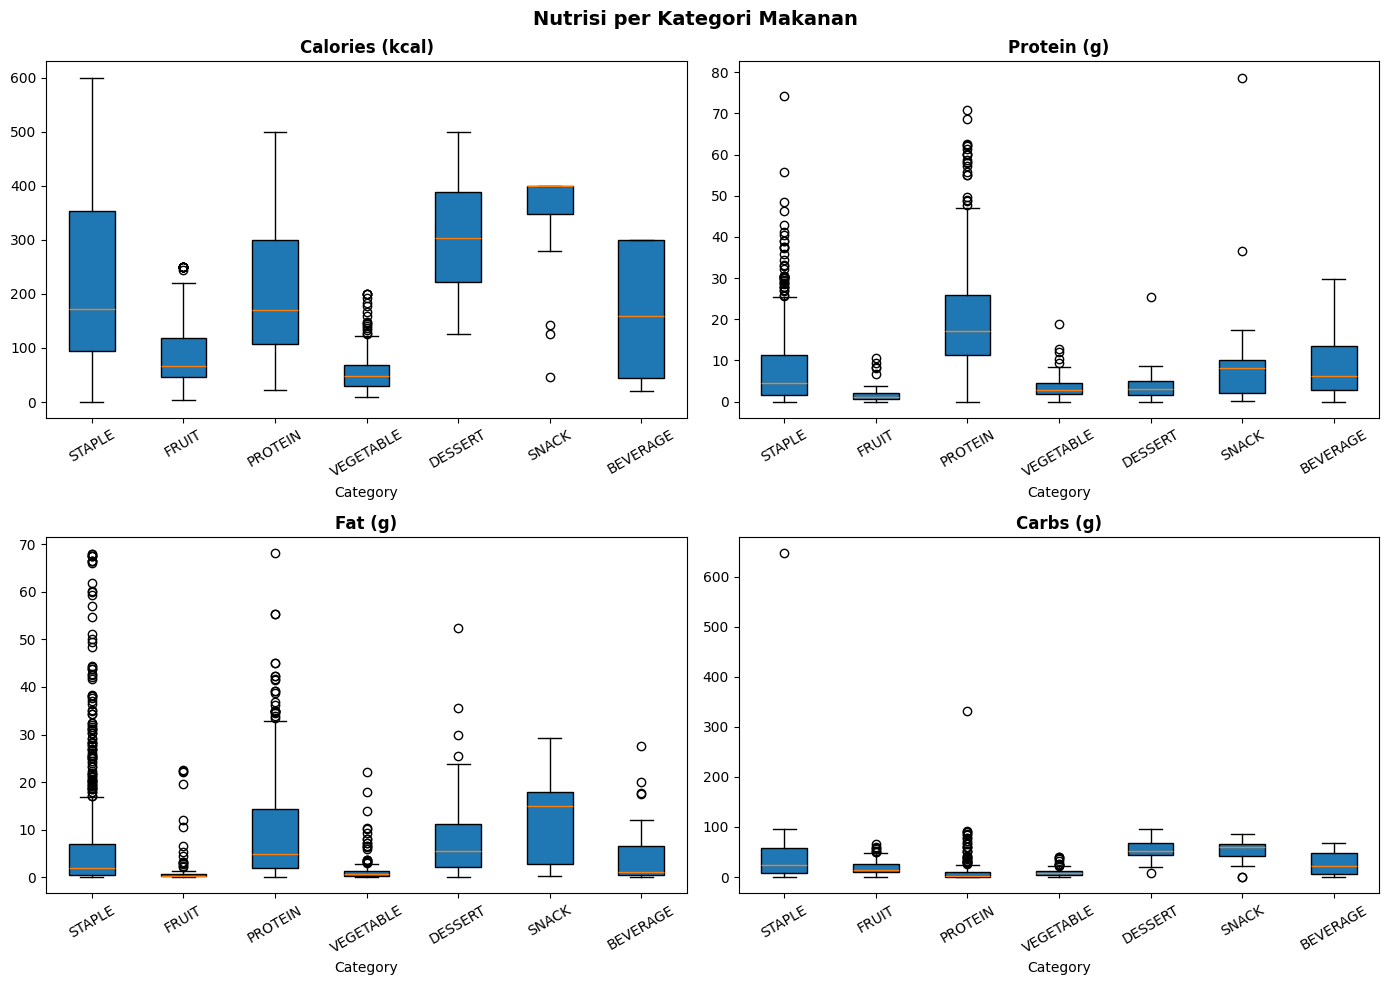

In [5]:
# ── 4. Nutrition per Category (Boxplot) ──
nutrients = ['calories_per_portion', 'protein_g', 'fat_g', 'carbs_g']
titles    = ['Calories (kcal)', 'Protein (g)', 'Fat (g)', 'Carbs (g)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col, title in zip(axes.flat, nutrients, titles):
    data_per_cat = [df[df['category'] == cat][col].dropna().values
                    for cat in df['category'].unique()]
    ax.boxplot(data_per_cat, labels=df['category'].unique(), patch_artist=True)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Category')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Nutrisi per Kategori Makanan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/eda/nutrition_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ── 5. Dietary Flags & Price Analysis ──
print('=== DIETARY FLAGS ===')
print(f'Halal:       {df["is_halal"].sum():4d} / {len(df)} ({df["is_halal"].mean()*100:.1f}%)')
print(f'Vegetarian:  {df["is_vegetarian"].sum():4d} / {len(df)} ({df["is_vegetarian"].mean()*100:.1f}%)')
print(f'Vegan:       {df["is_vegan"].sum():4d} / {len(df)} ({df["is_vegan"].mean()*100:.1f}%)')
print(f'Gluten-free: {df["is_gluten_free"].sum():4d} / {len(df)} ({df["is_gluten_free"].mean()*100:.1f}%)')

print('\n=== HARGA PER KATEGORI (median IDR) ===')
print(df.groupby('category')['estimated_price_idr'].median().sort_values(ascending=False).apply(lambda x: f'Rp {x:,.0f}').to_string())

print('\n=== CALORIE EFFICIENCY (kcal per Rp 1000) ===')
print(df.groupby('category')['cal_per_1000_idr'].mean().sort_values(ascending=False).round(1).to_string())

=== DIETARY FLAGS ===
Halal:       1327 / 1346 (98.6%)
Vegetarian:  1068 / 1346 (79.3%)
Vegan:       1033 / 1346 (76.7%)
Gluten-free: 1328 / 1346 (98.7%)

=== HARGA PER KATEGORI (median IDR) ===
category
PROTEIN      Rp 24,500
DESSERT      Rp 16,500
STAPLE       Rp 11,000
FRUIT         Rp 7,846
SNACK         Rp 6,500
VEGETABLE     Rp 6,500
BEVERAGE      Rp 5,500

=== CALORIE EFFICIENCY (kcal per Rp 1000) ===
category
SNACK        50.9
BEVERAGE     29.0
DESSERT      19.3
STAPLE       18.0
FRUIT        12.9
VEGETABLE     9.0
PROTEIN       7.8


In [7]:
# ── 6. Save EDA Summary ──
eda_summary = {
    'total_foods': int(len(df)),
    'categories': {k: int(v) for k, v in df['category'].value_counts().to_dict().items()},
    'cuisines':   {k: int(v) for k, v in df['cuisine'].value_counts().to_dict().items()},
    'dietary_flags': {
        'halal':       int(df['is_halal'].sum()),
        'vegetarian':  int(df['is_vegetarian'].sum()),
        'vegan':       int(df['is_vegan'].sum()),
        'gluten_free': int(df['is_gluten_free'].sum()),
    },
    'nutrition_avg': {
        'calories':  round(float(df['calories_per_portion'].mean()), 1),
        'protein_g': round(float(df['protein_g'].mean()), 1),
        'fat_g':     round(float(df['fat_g'].mean()), 1),
        'carbs_g':   round(float(df['carbs_g'].mean()), 1),
    },
    'price_median_idr': int(df['estimated_price_idr'].median()),
    'avg_name_length':  round(float(df['name_length'].mean()), 1),
    'avg_word_count':   round(float(df['word_count'].mean()), 1),
}
with open('output/eda/eda_summary.json', 'w', encoding='utf-8') as f:
    json.dump(eda_summary, f, indent=2, ensure_ascii=False)

print('OK EDA selesai.')
print(json.dumps(eda_summary, indent=2))

OK EDA selesai.
{
  "total_foods": 1346,
  "categories": {
    "STAPLE": 667,
    "PROTEIN": 321,
    "VEGETABLE": 157,
    "FRUIT": 100,
    "DESSERT": 49,
    "BEVERAGE": 29,
    "SNACK": 23
  },
  "cuisines": {
    "INDONESIAN_GENERAL": 1282,
    "INDONESIAN_PADANG": 27,
    "INDONESIAN_JAVA": 24,
    "INDONESIAN_SUNDA": 8,
    "WESTERN": 3,
    "ASIAN": 2
  },
  "dietary_flags": {
    "halal": 1327,
    "vegetarian": 1068,
    "vegan": 1033,
    "gluten_free": 1328
  },
  "nutrition_avg": {
    "calories": 195.8,
    "protein_g": 9.8,
    "fat_g": 7.0,
    "carbs_g": 25.0
  },
  "price_median_idr": 11500,
  "avg_name_length": 15.9,
  "avg_word_count": 2.6
}
